In [34]:
#%pip install scikit-plots

In [35]:
import pandas as pd 
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_predict
from joblib import dump, load
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

csv_path = Path("../fraudTrain.csv")
df_train = pd.read_csv(csv_path)
csv_path = Path("../fraudTest.csv")
df_test = pd.read_csv(csv_path)

carpeta_resultados = Path("resultados_entrenamiento")
carpeta_resultados.mkdir(exist_ok=True)
ruta_busqueda = carpeta_resultados / "busqueda_rf.joblib"

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

import scikitplot.decile.kds as kds

In [2]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

## Feature Engeneering

In [3]:
# features_eliminar_train = ['Unnamed: 0', 'cc_num', 'merchant, category', 'first', 'last', 'dob', 'cust_id', 
#                            'street', 'city', 'state', 'zip', 'lat', 'merch_lat', 'merch_long', 'trans_num', 'unix_time']

# features_candidatas_target_encoding = ['merchant, category']

In [4]:
def feature_engeneering(df, features):
    df = df.copy()
    df['trans_date_trans_time'] = pd.to_datetime(
        df['trans_date_trans_time'],
        errors='coerce'
    )
    df['day'] = df['trans_date_trans_time'].dt.day
    df['month'] = df['trans_date_trans_time'].dt.month
    df['year'] = df['trans_date_trans_time'].dt.year
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['night_flag'] = np.where((df['hour'].isin([22, 23, 0, 1, 2, 3])) , 1, 0)
    df['log_amt'] = df['amt'].apply(lambda x: np.log(x + 1))
    df['dob'] = pd.to_datetime(
        df['dob'],
        errors='coerce'
    )
    df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)
    df['male'] = np.where(df['gender'] == 'M', 1, 0)
    df['dif_lat']= (df['lat'] - df['merch_lat']).abs()
    df['dif_long']= (df['long'] - df['merch_long']).abs() 
    ## one hot encodign de categorys
    df = pd.get_dummies(df,columns=['category'],prefix='category',drop_first=True,dtype=int)

    # Variables de Benford calculadas fila por fila
    mantisa = df["amt"] / (10 ** np.floor(np.log10(df["amt"])))


    df["primeros_2"] = np.floor(
        (mantisa * 10).round(10)
    ).astype(int)

    df["benford_prob_2d"] = np.log10(
        1 + 1 / df["primeros_2"]
    )

    df["benford_surprisal_2d"] = -np.log(
        df["benford_prob_2d"]
    )

    
    df = df[features + ['is_fraud']]
    
    return df


In [5]:
features = ['day', 'month', 'year', 'hour', 'day_of_week', 'night_flag', 'amt',
                'log_amt', 'age', 'male', 'dif_lat', 'dif_long', 'city_pop', 

    # one hot encodign de categoria
    'category_food_dining',
    'category_gas_transport',
    'category_grocery_net',
    'category_grocery_pos',
    'category_health_fitness',
    'category_home',
    'category_kids_pets',
    'category_misc_net',
    'category_misc_pos',
    'category_personal_care',
    'category_shopping_net',
    'category_shopping_pos',
    'category_travel',

      # Benford
    #'primeros_2',
    'benford_surprisal_2d',
]

In [6]:
train_model = feature_engeneering(df_train, features)
test_model = feature_engeneering(df_test, features)

In [7]:
train_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 28 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   day                      1296675 non-null  int32  
 1   month                    1296675 non-null  int32  
 2   year                     1296675 non-null  int32  
 3   hour                     1296675 non-null  int32  
 4   day_of_week              1296675 non-null  int32  
 5   night_flag               1296675 non-null  int64  
 6   amt                      1296675 non-null  float64
 7   log_amt                  1296675 non-null  float64
 8   age                      1296675 non-null  int64  
 9   male                     1296675 non-null  int64  
 10  dif_lat                  1296675 non-null  float64
 11  dif_long                 1296675 non-null  float64
 12  city_pop                 1296675 non-null  int64  
 13  category_food_dining     1296675 non-null 

In [8]:
test_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   day                      555719 non-null  int32  
 1   month                    555719 non-null  int32  
 2   year                     555719 non-null  int32  
 3   hour                     555719 non-null  int32  
 4   day_of_week              555719 non-null  int32  
 5   night_flag               555719 non-null  int64  
 6   amt                      555719 non-null  float64
 7   log_amt                  555719 non-null  float64
 8   age                      555719 non-null  int64  
 9   male                     555719 non-null  int64  
 10  dif_lat                  555719 non-null  float64
 11  dif_long                 555719 non-null  float64
 12  city_pop                 555719 non-null  int64  
 13  category_food_dining     555719 non-null  int64  
 14  cate

In [9]:
X_train = train_model[features]
y_train = train_model['is_fraud']

X_test = test_model[features]
y_test = test_model['is_fraud']

print('Dimensión de X_train:', X_train.shape)
print('Dimensión de X_test:', X_test.shape)

print('\nDistribución del target en train:')
print(y_train.value_counts())

print('\nDistribución porcentual:')
print(y_train.value_counts(normalize=True))


Dimensión de X_train: (1296675, 27)
Dimensión de X_test: (555719, 27)

Distribución del target en train:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Distribución porcentual:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


In [ ]:


def evaluar_modelo(y_real, probabilidades,umbral=0.50): 
    """
    Evalúa un modelo binario a partir de las probabilidades pronosticadas.

    Parámetros
    ----------
    y_real:
        Valores reales del target.

    probabilidades:
        Probabilidades pronosticadas para la clase fraude.

    umbral:
        Probabilidasind mínima para clasificar una observación como fraude.
    """

    # Convertir probabilidades en predicciones
    predicciones = (
        probabilidades >= umbral
    ).astype(int)

    # Matriz de confusión
    matriz = confusion_matrix(
        y_real,
        predicciones,
        labels=[0, 1]
    )

    tn, fp, fn, tp = matriz.ravel()

    # Calcular métricas
    metricas = {
        'umbral': umbral,
        'accuracy': accuracy_score(y_real, predicciones),
        'precision': precision_score(
            y_real,
            predicciones,
            zero_division=0
        ),
        'recall': recall_score(
            y_real,
            predicciones,
            zero_division=0
        ),
        'f1': f1_score(
            y_real,
            predicciones,
            zero_division=0
        ),
        'roc_auc': roc_auc_score(
            y_real,
            probabilidades
        ),
        'pr_auc': average_precision_score(
            y_real,
            probabilidades
        ),
        'verdaderos_negativos': tn,
        'falsos_positivos': fp,
        'falsos_negativos': fn,
        'verdaderos_positivos': tp
    }

    # Mostrar resultados
    print(f'Umbral utilizado: {umbral:.2f}')

    print('\nMatriz de confusión:')
    print(matriz)

    print('\nMétricas:')
    print(f"Accuracy:  {metricas['accuracy']:.4f}")
    print(f"Precision: {metricas['precision']:.4f}")
    print(f"Recall:    {metricas['recall']:.4f}")
    print(f"F1:        {metricas['f1']:.4f}")
    print(f"ROC-AUC:   {metricas['roc_auc']:.4f}")
    print(f"PR-AUC:    {metricas['pr_auc']:.4f}")

    return metricas, predicciones

## Entrenamiento del modelo

In [11]:
#Entrenar el random forest baseline

modelo_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)


In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [13]:
folds = np.zeros(len(y_train), dtype=int)

for i, (_, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    folds[val_idx] = i

df_folds = pd.DataFrame({
    'fold': folds,
    'fraude': y_train.values
})

## group by por fold para ver la media de fraude
df_folds.groupby('fold')['fraude'].agg([
    'count',
    'sum',
    'mean'
])

,count,sum,mean
fold,,,
1,259335,1501,0.005788
2,259335,1501,0.005788
3,259335,1501,0.005788
4,259335,1501,0.005788
5,259335,1502,0.005792


In [14]:


scoring = {
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc'
}

resultados_baseline_cv = cross_validate(
    estimator=modelo_baseline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=1
)

resumen_baseline_cv = pd.DataFrame({
    'PR-AUC train': resultados_baseline_cv['train_pr_auc'],
    'PR-AUC validation': resultados_baseline_cv['test_pr_auc'],
    'ROC-AUC validation': resultados_baseline_cv['test_roc_auc']
})

resumen_baseline_cv

,PR-AUC train,PR-AUC validation,ROC-AUC validation
0,0.971142,0.900025,0.997619
1,0.969048,0.890732,0.997002
2,0.968523,0.889906,0.997101
3,0.967614,0.894109,0.996475
4,0.970258,0.894554,0.997202


In [15]:
dump(
    {
        'resultados_baseline_cv': resultados_baseline_cv,
        'resumen_baseline_cv': resumen_baseline_cv
    },
    carpeta_resultados / "baseline_cv.joblib"
)

['resultados_entrenamiento/baseline_cv.joblib']

In [16]:
print(
    'PR-AUC promedio del baseline:',
    round(resumen_baseline_cv['PR-AUC validation'].mean(), 4)
)

print(
    'Desvío estándar:',
    round(resumen_baseline_cv['PR-AUC validation'].std(), 4)
)

PR-AUC promedio del baseline: 0.8939
Desvío estándar: 0.004


In [17]:
# Optimización de hiperparámetros con validación cruzada


modelo_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

parametros = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [1, 5, 20],
    'class_weight': [None, 'balanced']
}



busqueda_rf = RandomizedSearchCV(
    estimator=modelo_rf,
    param_distributions=parametros,
    n_iter=5,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

if ruta_busqueda.exists():

    print("Cargando búsqueda previamente entrenada...")

    busqueda_rf = load(ruta_busqueda)

else:

    print("Entrenando modelos...")

    busqueda_rf.fit(X_train, y_train)

    dump(
    busqueda_rf,
    carpeta_resultados / "busqueda_rf.joblib",
    compress=3
    )

mejor_modelo = busqueda_rf.best_estimator_

print('Mejores hiperparámetros:', busqueda_rf.best_params_)
print('Mejor PR-AUC:', round(busqueda_rf.best_score_, 4))

Cargando búsqueda previamente entrenada...
Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': None}
Mejor PR-AUC: 0.9131


In [18]:
mejor_modelo

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [19]:
resultados_busqueda = pd.DataFrame(
    busqueda_rf.cv_results_
)

columnas_resultados = [
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_leaf',
    'param_class_weight',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]

resultados_busqueda = (
    resultados_busqueda[columnas_resultados]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
)

resultados_busqueda

,param_n_estimators,param_max_depth,param_min_samples_leaf,param_class_weight,mean_train_score,mean_test_score,std_test_score,mean_fit_time
0,200,20,1,None,0.999661,0.913070,0.003216,73.172582
1,200,20,5,balanced,0.994781,0.903812,0.003091,75.282107
2,100,20,5,balanced,0.994521,0.903784,0.002991,91.039737
3,100,15,5,None,0.951572,0.898658,0.003366,85.476678
4,300,15,20,balanced,0.949607,0.893521,0.003600,223.230115


In [20]:
# Probabilidades out-of-fold para optimizar el umbral sin usar test
ruta_oof = carpeta_resultados / "probabilidades_oof_rf.csv.gz"

if ruta_oof.exists():
    df_oof = pd.read_csv(ruta_oof)
else:
    probabilidades_oof = cross_val_predict(
        estimator=mejor_modelo,
        X=X_train,
        y=y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1,
        verbose=1
    )[:, 1]

    df_oof = pd.DataFrame({
        "id": X_train.index.to_numpy(),
        "fold": folds,
        "prob_fraude": probabilidades_oof,
        "fraude_real": y_train.to_numpy()
    })
    df_oof.to_csv(ruta_oof, index=False, compression="gzip")

for numero_fold in range(1, cv.n_splits + 1):
    ruta_fold = carpeta_resultados / f"probabilidades_oof_fold_{numero_fold}.csv"
    if not ruta_fold.exists():
        (
            df_oof.loc[df_oof["fold"] == numero_fold, ["id", "prob_fraude", "fraude_real"]]
            .to_csv(ruta_fold, index=False)
        )

df_oof.groupby("fold")["fraude_real"].agg(["count", "sum", "mean"])

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  5.4min finished


,count,sum,mean
fold,,,
1,259335,1501,0.005788
2,259335,1501,0.005788
3,259335,1501,0.005788
4,259335,1501,0.005788
5,259335,1502,0.005792


In [42]:
import pandas as pd
from pathlib import Path

archivo_entrada = Path(
    "/Users/vaniacaffarattidonalisio/Documents/data_science_tp/"
    "notebooks/Parte-2/Entrenamiento/resultados_entrenamiento/"
    "probabilidades_oof_fold_1.csv"
)

archivo_salida = archivo_entrada.with_name(
    "probabilidades_oof_fold_1_coma_decimal.csv"
)

df = pd.read_csv(archivo_entrada)

df.to_csv(
    archivo_salida,
    index=False,
    sep=";",
    decimal=","
)

print(f"Archivo guardado en: {archivo_salida}")

Archivo guardado en: /Users/vaniacaffarattidonalisio/Documents/data_science_tp/notebooks/Parte-2/Entrenamiento/resultados_entrenamiento/probabilidades_oof_fold_1_coma_decimal.csv


In [21]:
from sklearn.base import clone

modelo_baseline_final = clone(modelo_baseline)

modelo_baseline_final.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

## Metricas Umbral 0,5

In [ ]:
probabilidades_baseline_test = (
    modelo_baseline_final.predict_proba(X_test)[:, 1]
)

probabilidades_optimizado_test = (
    mejor_modelo.predict_proba(X_test)[:, 1]
)

In [41]:
probabilidades_optimizado_test

array([4.99285224e-06, 1.15196285e-05, 1.01906161e-06, ...,
       4.97888439e-05, 2.90793366e-03, 1.07395191e-04], shape=(555719,))

In [23]:
print('MODELO BASELINE')

metricas_baseline_test, predicciones_baseline_test = evaluar_modelo(
    y_real=y_test,
    probabilidades=probabilidades_baseline_test,
    umbral=0.50
)

MODELO BASELINE
Umbral utilizado: 0.50

Matriz de confusión:
[[548881   4693]
 [   131   2014]]

Métricas:
Accuracy:  0.9913
Precision: 0.3003
Recall:    0.9389
F1:        0.4550
ROC-AUC:   0.9962
PR-AUC:    0.8546


In [24]:
metricas_test, predicciones_test = evaluar_modelo(
    y_real=y_test,
    probabilidades=probabilidades_optimizado_test,
    umbral=0.50
)

Umbral utilizado: 0.50

Matriz de confusión:
[[553470    104]
 [   542   1603]]

Métricas:
Accuracy:  0.9988
Precision: 0.9391
Recall:    0.7473
F1:        0.8323
ROC-AUC:   0.9950
PR-AUC:    0.8770


## Metricas Umbral Solver

In [46]:
### Seleccion de Umbral
umbral = 0.0263

In [47]:
print('MODELO BASELINE')

metricas_baseline_test, predicciones_baseline_test = evaluar_modelo(
    y_real=y_test,
    probabilidades=probabilidades_baseline_test,
    umbral=umbral
)

MODELO BASELINE
Umbral utilizado: 0.03

Matriz de confusión:
[[448232 105342]
 [     5   2140]]

Métricas:
Accuracy:  0.8104
Precision: 0.0199
Recall:    0.9977
F1:        0.0390
ROC-AUC:   0.9962
PR-AUC:    0.8546


In [48]:
metricas_test, predicciones_test = evaluar_modelo(
    y_real=y_test,
    probabilidades=probabilidades_optimizado_test,
    umbral=umbral
)

Umbral utilizado: 0.03

Matriz de confusión:
[[547759   5815]
 [   126   2019]]

Métricas:
Accuracy:  0.9893
Precision: 0.2577
Recall:    0.9413
F1:        0.4046
ROC-AUC:   0.9950
PR-AUC:    0.8770


In [52]:
sum(probabilidades_optimizado_test > umbral)/len(probabilidades_optimizado_test)*100

np.float64(1.409705264711122)

## Feature Importance

In [30]:
# Permutation importance sobre datos no utilizados para entrenar
resultado_importancia = permutation_importance(
    estimator=mejor_modelo,
    X=X_test,
    y=y_test,
    #average_precision = resume el desempeño de la curva precision-recall utilizando 
    # las probabilidades pronosticadas para la clase positiva.
    scoring="average_precision",
    n_repeats=5, # es el valor predeterminado de la libreria
    random_state=42,
    n_jobs=-1
)

importancia_predictores = (
    pd.DataFrame({
        "predictor": X_test.columns,
        "importancia_media": resultado_importancia.importances_mean,
        "importancia_std": resultado_importancia.importances_std
    })
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

importancia_predictores

,predictor,importancia_media,importancia_std
0,log_amt,0.469809,0.005199
1,category_grocery_pos,0.299909,0.002438
2,amt,0.265088,0.005178
3,category_gas_transport,0.234665,0.001606
4,hour,0.195493,0.004696
5,age,0.126498,0.002461
6,night_flag,0.039139,0.001517
7,category_misc_pos,0.037701,0.000712
8,benford_surprisal_2d,0.036076,0.001027
9,category_grocery_net,0.027783,0.000425


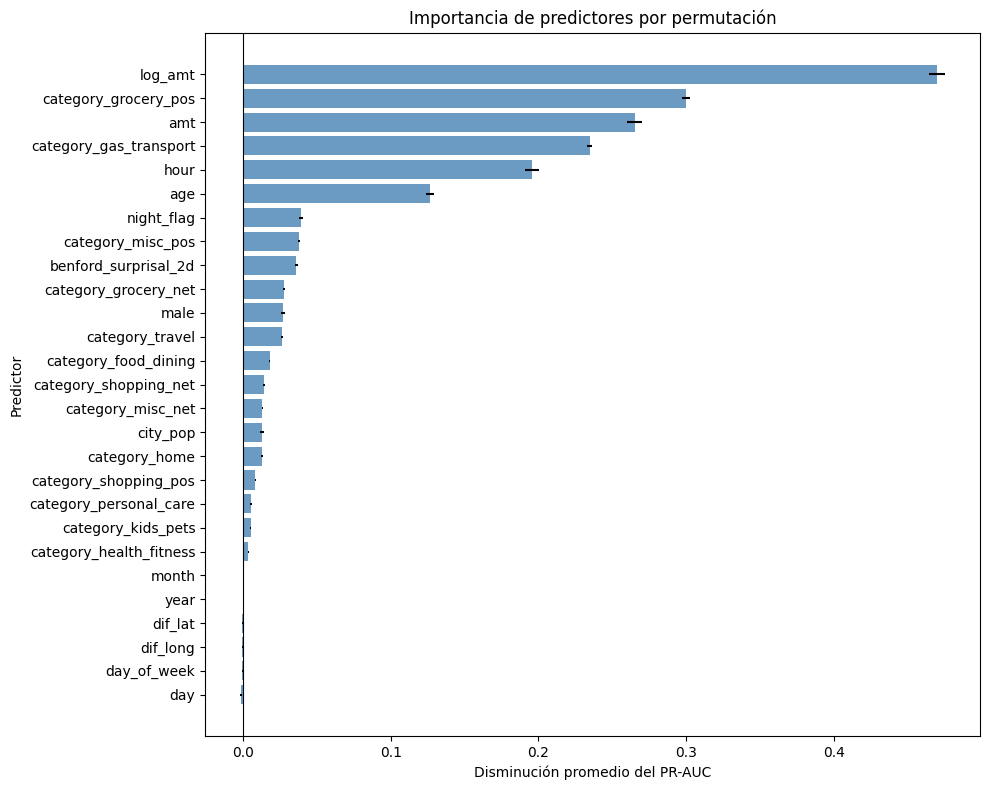

In [28]:
importancia_grafico = importancia_predictores.sort_values(
    "importancia_media",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    importancia_grafico["predictor"],
    importancia_grafico["importancia_media"],
    xerr=importancia_grafico["importancia_std"],
    color="steelblue",
    alpha=0.8
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Importancia de predictores por permutación")
ax.set_xlabel("Disminución promedio del PR-AUC")
ax.set_ylabel("Predictor")

plt.tight_layout()
plt.show()

## Lift Gain Charts

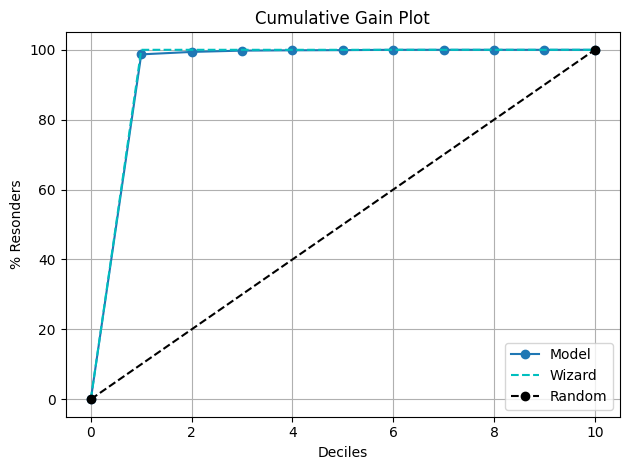

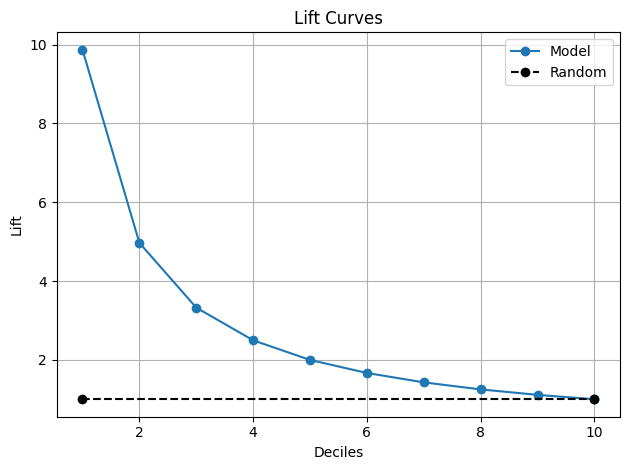

<Axes: title={'center': 'Lift Curves'}, xlabel='Deciles', ylabel='Lift'>

In [ ]:
kds.plot_cumulative_gain(
    y_test,
    probabilidades_optimizado_test
)

kds.plot_lift(
    y_test,
    probabilidades_optimizado_test
)

### Gain:
Revisando el 10% de las transacciones con mayor riesgo, detectás aproximadamente el 98–99% de los fraudes.
Revisando el 20%, prácticamente llegás al 100%.
La curva del modelo casi coincide con Wizard, que representa el ordenamiento perfecto.
Random muestra lo esperado seleccionando transacciones al azar

## Lift:
En el primer decil, el lift es aproximadamente 9,8.
Eso significa que el 10% de transacciones con mayor riesgo concentra casi 10 veces más fraudes que una muestra aleatoria del mismo tamaño.

LABELS INFO:

 prob_min         : Minimum probability in a particular decile
 prob_max         : Minimum probability in a particular decile
 prob_avg         : Average probability in a particular decile
 cnt_events       : Count of events in a particular decile
 cnt_resp         : Count of responders in a particular decile
 cnt_non_resp     : Count of non-responders in a particular decile
 cnt_resp_rndm    : Count of responders if events assigned randomly in a particular decile
 cnt_resp_wiz     : Count of best possible responders in a particular decile
 resp_rate        : Response Rate in a particular decile [(cnt_resp/cnt_cust)*100]
 cum_events       : Cumulative sum of events decile-wise 
 cum_resp         : Cumulative sum of responders decile-wise 
 cum_resp_wiz     : Cumulative sum of best possible responders decile-wise 
 cum_non_resp     : Cumulative sum of non-responders decile-wise 
 cum_events_pct   : Cumulative sum of percentages of events decile-wise 
 cum_resp_pct     : Cu

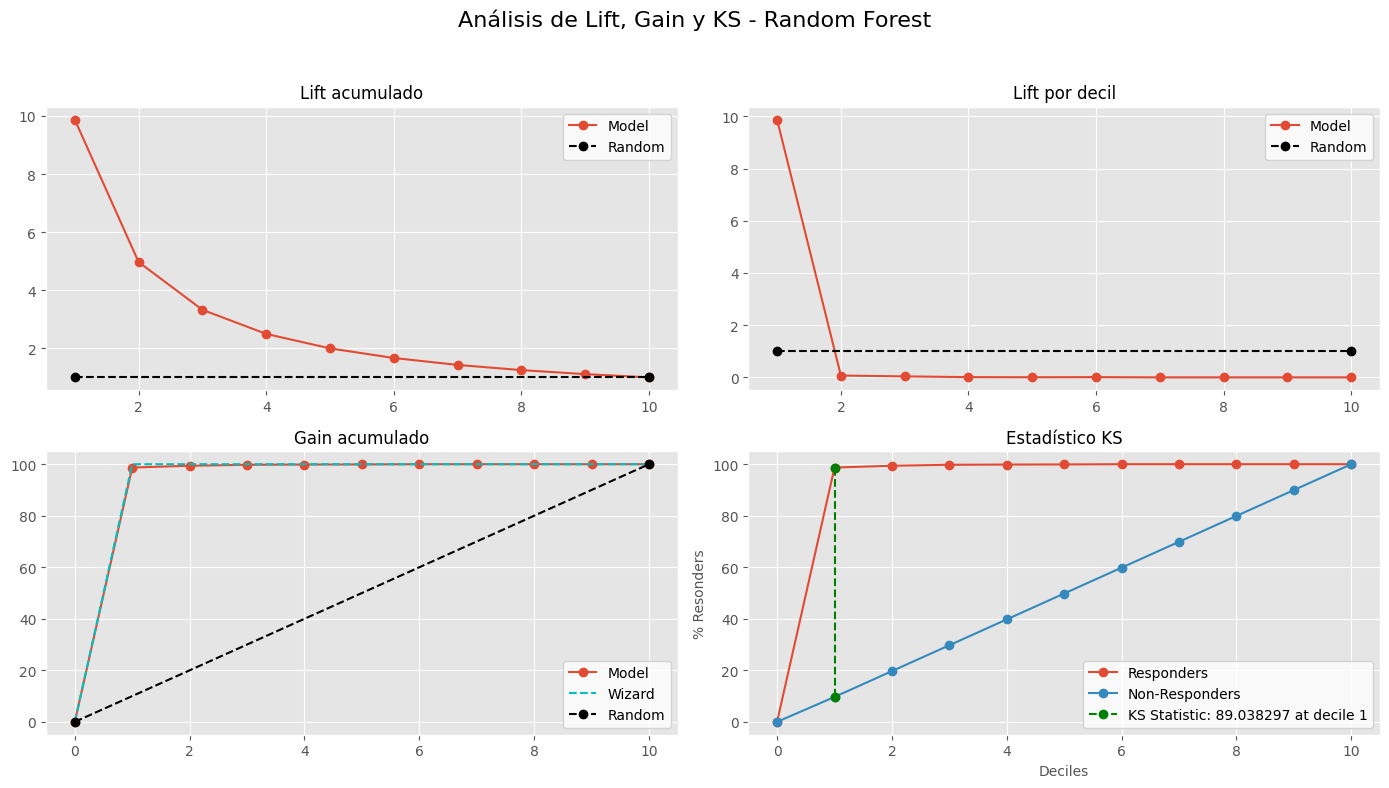

In [40]:
kds.report(
    y_test,
    probabilidades_optimizado_test,
    plot_style='ggplot',
    show_fig=False
)
fig = plt.gcf()
graficos = fig.axes

titulos = [
    'Lift acumulado',
    'Lift por decil',
    'Gain acumulado',
    'Estadístico KS'
]

for grafico, titulo in zip(graficos, titulos):
    grafico.set_title(titulo)

fig.suptitle(
    'Análisis de Lift, Gain y KS - Random Forest',
    fontsize=16
)

fig.set_size_inches(14, 8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()